# Crop Recommendation Model Training

## Step 1 - Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2 - Load Dataset

In [3]:
df = pd.read_csv("../dataset/Crop_recommendation.csv")

## Step 3 - Display First Five Rows

In [ ]:
df.head()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label,Unnamed: 8,Unnamed: 9
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,NaN,NaN
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,NaN,NaN
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,NaN,NaN
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,NaN,NaN
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,NaN,NaN


## Step 4 - Dataset Shape

In [6]:
df.shape
df.columns

Index(['Nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph',
       'rainfall', 'label', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='str')

In [ ]:
df = df.drop(columns=["Unnamed: 8", "Unnamed: 9"])
df.columns

KeyError: "['Unnamed: 8', 'Unnamed: 9'] not found in axis"

In [12]:
df.columns.tolist()


['Nitrogen',
 'phosphorus',
 'potassium',
 'temperature',
 'humidity',
 'ph',
 'rainfall',
 'label']

In [13]:
df.columns = [
    "nitrogen",
    "phosphorus",
    "potassium",
    "temperature",
    "humidity",
    "ph",
    "rainfall",
    "label"
]

In [14]:
df.columns.tolist()

['nitrogen',
 'phosphorus',
 'potassium',
 'temperature',
 'humidity',
 'ph',
 'rainfall',
 'label']

In [15]:
df.shape

(2200, 8)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nitrogen     2200 non-null   int64  
 1   phosphorus   2200 non-null   int64  
 2   potassium    2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [17]:
df.describe()

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [18]:
df.isnull().sum()

nitrogen       0
phosphorus     0
potassium      0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

## Step 11 - Data Visualization

In [21]:
import matplotlib.pyplot as plt

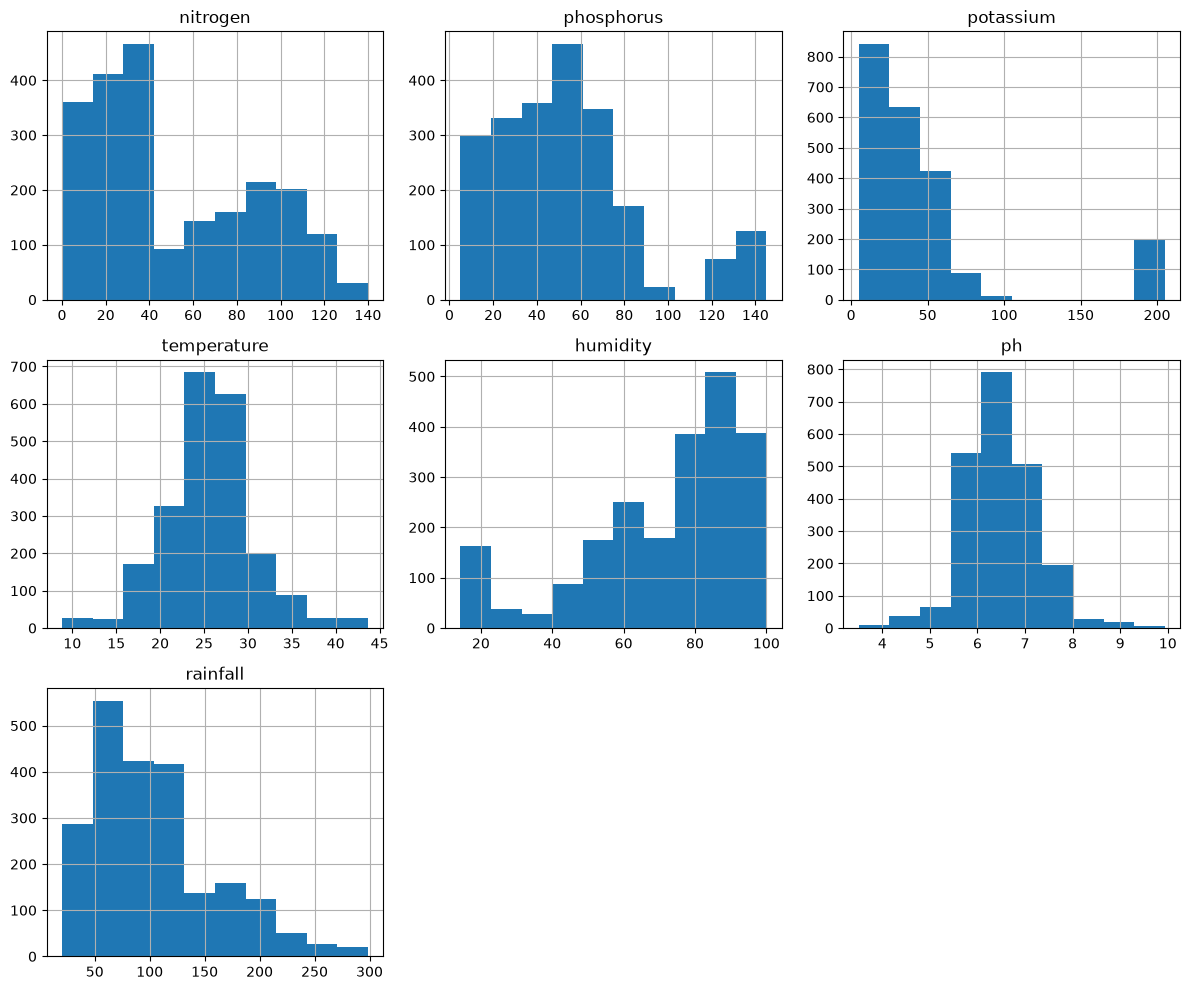

In [22]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

## Step 12 - Detect Outliers

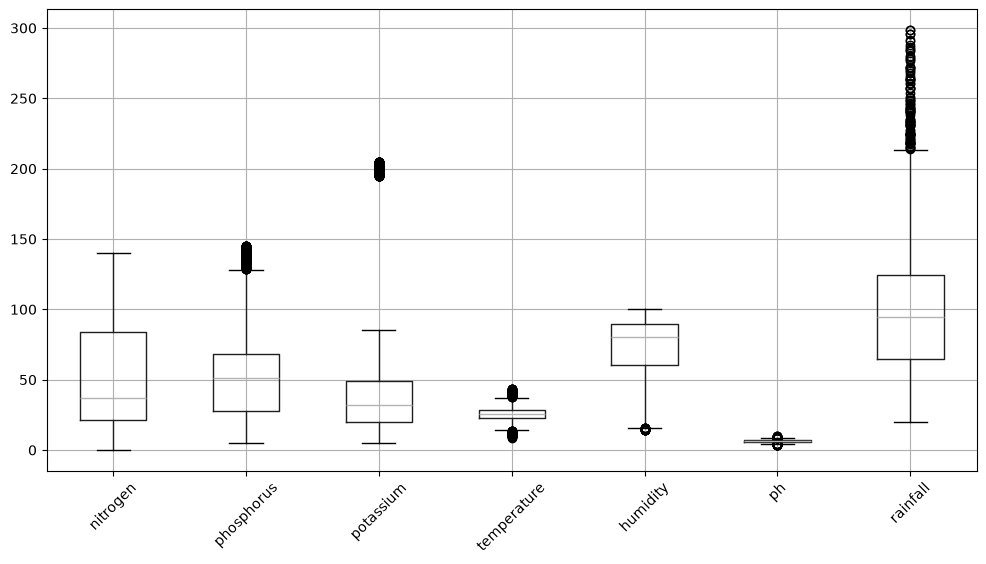

In [23]:
plt.figure(figsize=(12,6))

df.boxplot()

plt.xticks(rotation=45)

plt.show()

In [24]:
correlation = df.drop("label", axis=1).corr()

correlation

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
nitrogen,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
phosphorus,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
potassium,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


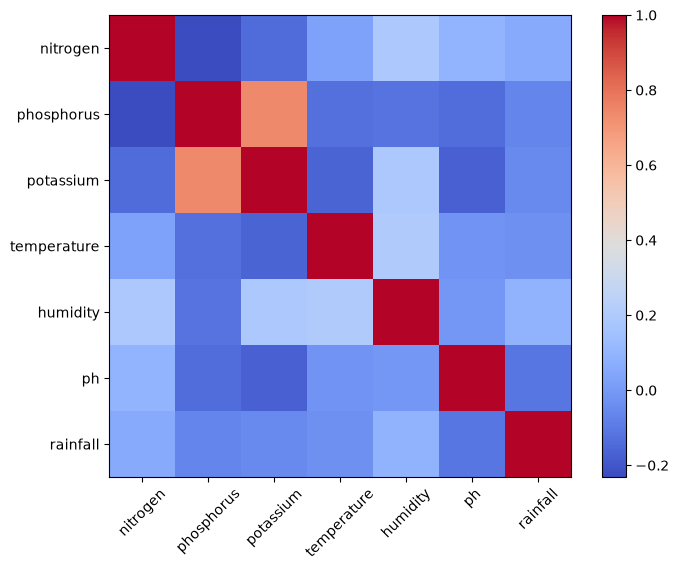

In [25]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.show()

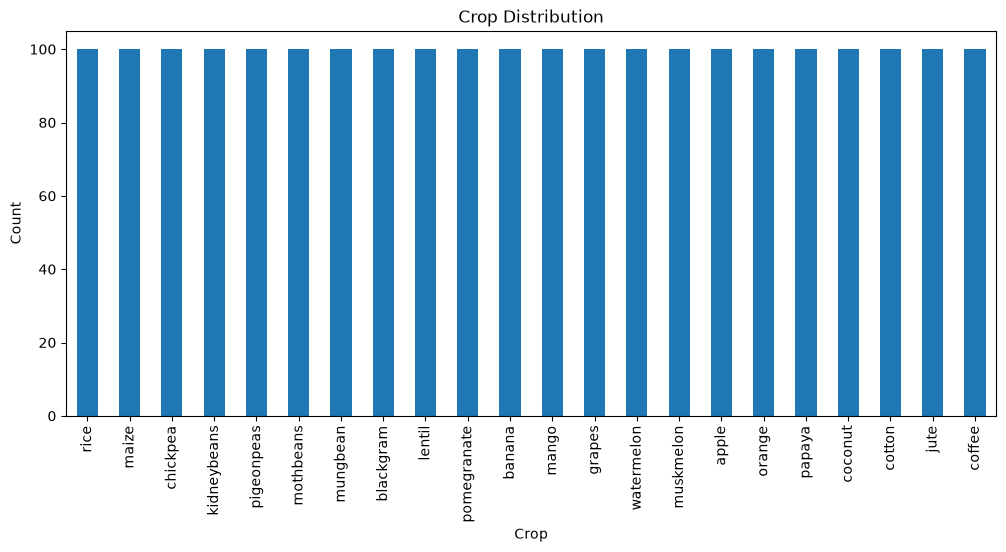

In [26]:
df["label"].value_counts().plot(kind="bar", figsize=(12,5))

plt.xlabel("Crop")

plt.ylabel("Count")

plt.title("Crop Distribution")

plt.xticks(rotation=90)

plt.show()

## Step 17 - Separate Features and Target Variable

In [27]:
X = df.drop("label", axis=1)

y = df["label"]

In [28]:
X.head()

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [29]:
y.head()

0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: str

## Step 18 - Encode Crop Labels

In [30]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [31]:
y[:10]

array([20, 20, 20, 20, 20, 20, 20, 20, 20, 20])

## Step 19 - Split Training and Testing Data

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print(X_train.shape)
print(X_test.shape)

(1760, 7)
(440, 7)
